In [ ]:
#  data used for DIM_Ads

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('E:/NOUR/Documents/PFE/data/youtube ads.csv')

In [5]:
df

,Date,Ads Revenue (Mn)
0,31-03-2019,3025000000
1,30-06-2019,3603000000
2,30-09-2019,3804000000
3,31-12-2019,4717000000
4,31-03-2020,4038000000
5,30-06-2020,3812000000
6,30-09-2020,5037000000
7,31-12-2020,6885000000
8,31-03-2021,6005000000
9,30-06-2021,7002000000


In [6]:
df['Date'] = df['Date'].astype('datetime64')

C:\Users\NOUR\AppData\Local\Temp\ipykernel_18888\1947097528.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = df['Date'].astype('datetime64')


In [7]:
df['year'] = df['Date'].dt.year


In [ ]:
import pymongo
from pymongo import MongoClient
con = pymongo.MongoClient("mongodb://localhost:27017/")
db = con.DCSTEC
collection = db.Sales

In [ ]:
data = all_data.to_dict(orient='records')
collection.insert_many(data)

In [8]:
df_year = df.groupby('year')


In [9]:
df_mean_revenue = df_year.mean()
print(df_mean_revenue)

      Ads Revenue (Mn)
year                  
2019      3.787250e+09
2020      4.943000e+09
2021      7.211250e+09
2022      7.310750e+09
2023      6.693000e+09


C:\Users\NOUR\AppData\Local\Temp\ipykernel_18888\3618607036.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_mean_revenue = df_year.mean()


In [10]:
df_total_revenue = df_year.sum()
df_total_revenue

C:\Users\NOUR\AppData\Local\Temp\ipykernel_18888\791882422.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_total_revenue = df_year.sum()


,Ads Revenue (Mn)
year,
2019,15149000000
2020,19772000000
2021,28845000000
2022,29243000000
2023,6693000000


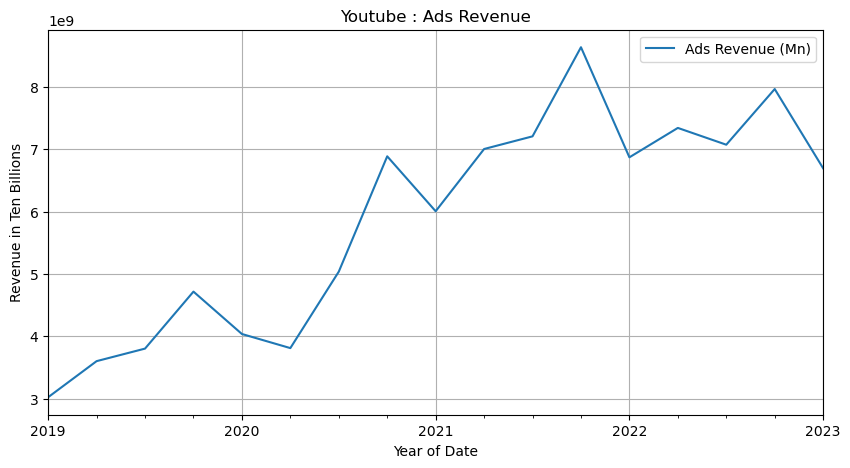

In [11]:
df.plot(x='Date',y ='Ads Revenue (Mn)',kind='line',title='Youtube : Ads Revenue',figsize = (10,5))
plt.xlabel('Year of Date')
plt.ylabel('Revenue in Ten Billions')
plt.grid(True)
plt.show()

In [12]:
change_revenue_percent = list()
row_index = 0
for i in df['Ads Revenue (Mn)']:
    if row_index == 0:
        previous_revenue = i
        row_index = row_index +1
    else:
        change_revenue_percent.append(((i - previous_revenue)*100)/previous_revenue)
        row_index = row_index +1
    previous_revenue = i
    
change_revenue_percent

[19.107438016528924,
 5.578684429641965,
 24.00105152471083,
 -14.394742421030315,
 -5.596830113917781,
 32.13536201469045,
 36.688505062537224,
 -12.781408859840232,
 16.602830974188176,
 2.8991716652385033,
 19.819569743233867,
 -20.433221359898067,
 6.85689328868831,
 -3.664850136239782,
 12.614905953896196,
 -15.948763029009168]

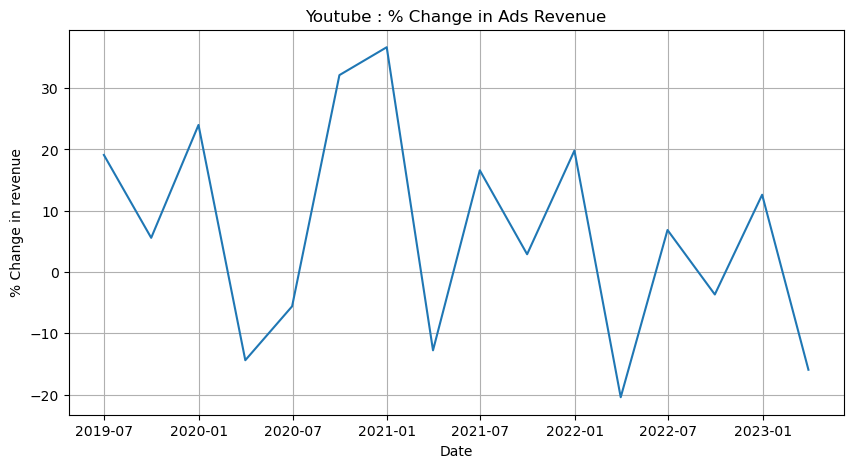

In [13]:
plt.figure(figsize=(10,5))
plt.plot(df.iloc[:,0][1:],change_revenue_percent)
plt.xlabel('Date')
plt.ylabel('% Change in revenue')
plt.title('Youtube : % Change in Ads Revenue')
plt.grid(True)
plt.show()

In [14]:
df2 = pd.read_csv('E:/NOUR/Documents/PFE/data/Dummy Data HSS.csv',encoding='latin-1')

In [15]:
df2.head()

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181


In [20]:
df2.isna().any()

TV              False
Radio           False
Social Media    False
Influencer      False
Sales           False
dtype: bool

In [18]:
df2.dropna(inplace= True)

<Axes: xlabel='TV', ylabel='Sales'>

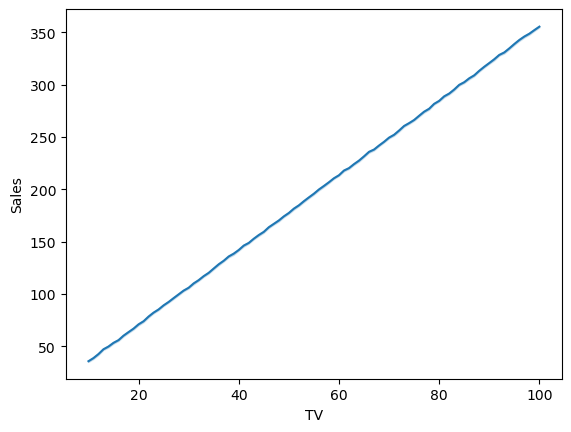

In [24]:
import seaborn as sns
sns.lineplot(x='TV', y='Sales', data=df2)



<Axes: xlabel='Influencer', ylabel='Sales'>

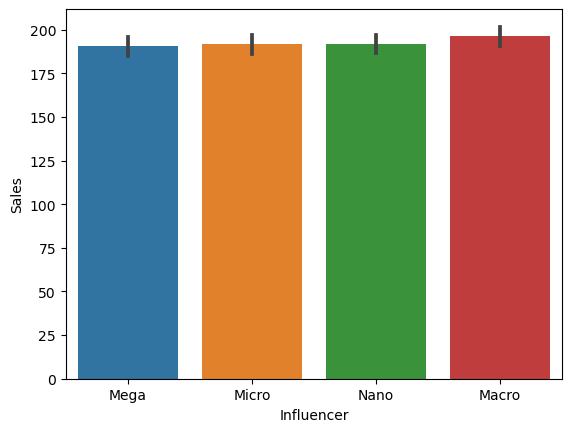

In [27]:
sns.barplot(x='Influencer', y='Sales', data=df2)


<Axes: xlabel='Social Media', ylabel='Sales'>

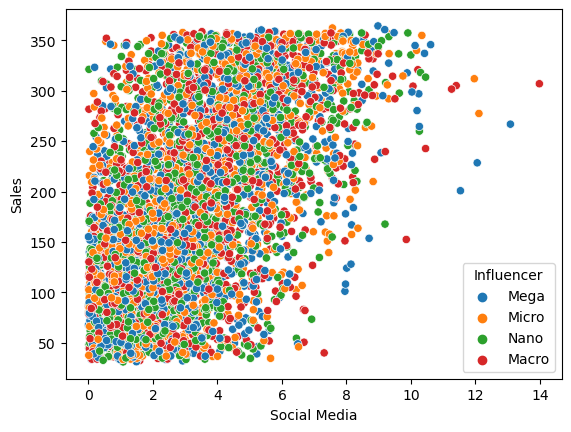

In [30]:
sns.scatterplot(x='Social Media', y='Sales', data=df2,hue='Influencer')


<Axes: xlabel='Radio', ylabel='Sales'>

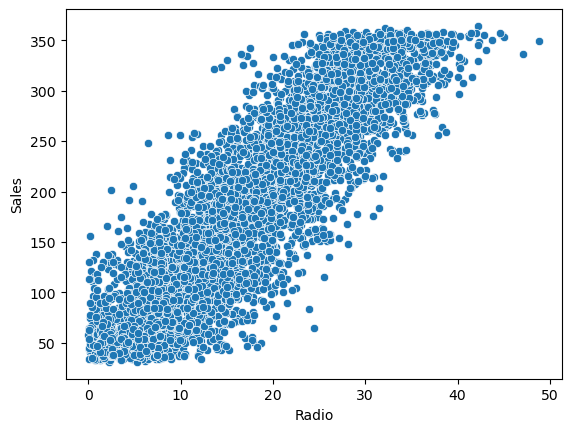

In [32]:
 sns.scatterplot(x='Radio',y='Sales', data=df2)
# same for others

In [38]:
df3=df2

In [39]:
df3.replace('Nano',0,inplace=True)
df3.replace('Micro',1,inplace=True)
df3.replace('Macro',2,inplace=True)
df3.replace('Mega',3,inplace=True)

In [43]:
dataset = pd.DataFrame(df3,columns=('TV','Radio','Social Media','Influencer','Sales'))

In [44]:
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:,-1].values

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=0)

In [46]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train,y_train)

LinearRegression()

In [47]:
y_pred=regressor.predict(X_test)

In [48]:
seedata = np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1)

In [49]:
data2 = pd.DataFrame(seedata,columns=('Prediction','Real'))

In [50]:
data2.head()

,Prediction,Real
0,277.674134,277.241337
1,234.920992,236.158713
2,167.291858,167.724668
3,163.639587,159.068412
4,167.292086,170.468878
